## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 7 Numerical solution for the stochastic dynamic optimization
### Shutao Cao

### Credit

This notebook was adapted from [Optimal Growth I: The Stochastic Optimal Growth Model](https://python.quantecon.org/optgrowth.html) at [quantecon.org](quantecon.org)

### Stochastic Growth: Model

\begin{align*}
            & \quad V(z,k) = \max_{\{c,k'\}} \big[u(c) + \beta \mathbb{E} V(z',k')\big] \\
            & \quad  \text{s.t.} \\
            & \quad  c + k \le f(z,k) + (1-\delta)k. \\
            & \quad  k'\ge 0. \\
            & \quad  z, k \ \text{are given}
        \end{align*}
        

NOTE: In the computation below following the quantecon.org, $z$ is made an IID random variable, which is different from the lecture slides.

### Stochastic growth: numerical solution by VFI

We use the value function iteration (VFI) to numerically solve the Bellman equation. To simplify the coding, we define $y = f(z,k)$, $z$ and $k$ are state variables, thus $y$ is also a state variable, though a derived state.

Given the tranformation, choosing the optimal $k'$ is equivalent to choosing an optimal $y'$ since $y' = f(z',k')$.

VFI algorithm is:

0. Discretize the state variable $y$ into grid points, $y = [\underline{y},y_2,\cdots,\overline{y}]$.

1. Guess a value for the value function $V^0$ for each state $y_i$ for all $i$.

2. Update the values for the value fuction 
$$ V^1(y) = \max_{\{c,y'\}} \big[u(c) + \beta \mathbb{E} V^0(y')\big]$$

3. Iteration, in the $m$th iteration, update value function values as
$$ V^{m+1}(y) = \max_{\{c,y'\}} \big[u(c) + \beta \mathbb{E} V^{m}(y')\big]$$

4. Stopping rule: if $V^{m+1}$ is close to $V^{m}$ stop; otherwise go back to step 3.

#### Remarks on the algorithm

2. If $y'$ is chosen to be off grid, we need to interpolate the value function, because the iteration is on the value function values on grid points.

3. We need to compute the expectation, by numerical integration, 
$$\mathbb{E} V^{m}(y') = \int_{z'} V^{m}(y') \phi(z'|z) dz'$$

4. The stopping rule is dictated by the miminmum of $|V^{m+1} - V^{m}|$.

### Implementing VFI

We need to specify function forms and assign parameters values

Production function and utility function:
$$
f(k) = k^{\alpha}
\quad \text{and} \quad
u(c) = \ln c
$$

If there are no shocks ($z$ is a constant), the problem has the analytical solution
$$
V(y) =
\frac{\ln (1 - \alpha \beta) }{ 1 - \beta} +
\frac{(\mu + \alpha \ln (\alpha \beta))}{1 - \alpha}
 \left[
     \frac{1}{1- \beta} - \frac{1}{1 - \alpha \beta}
 \right] +
 \frac{1}{1 - \alpha \beta} \ln y
$$

and the optimal consumption is 
$$
\sigma^*(y) = (1 - \alpha \beta ) y
$$

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
%matplotlib inline

#### Scalar Maximization

To maximize the right hand side of the Bellman equation, we are going to use
the `minimize_scalar` routine from SciPy.

Since we are maximizing rather than minimizing, we will use the fact that the
maximizer of $ g $ on the interval $ [a, b] $ is the minimizer of
$ -g $ on the same interval.

To this end, and to keep the interface tidy, we will wrap `minimize_scalar`
in an outer function as follows:

In [44]:
def maximize(g, a, b, args):
    """
    Maximize the function g over the interval [a, b].

    We use the fact that the maximizer of g on any interval is
    also the minimizer of -g.  The tuple args collects any extra
    arguments to g.

    Returns the maximal value and the maximizer.
    """

    objective = lambda x: -g(x, *args)
    result = minimize_scalar(objective, bounds=(a, b), method='bounded')
    maximizer, maximum = result.x, -result.fun
    return maximizer, maximum

#### Distribution of $z$

Let $ \phi $ be the distribution of $ z := \exp(\mu + s \varepsilon) $ where

- $ \varepsilon $ is a shock with the standard normal distribution
- $ \mu $ is the shock location parameter and  
- $ s $ is the shock scale parameter.  

We store this and other primitives of the optimal growth model in a class.

The class, defined below, combines both parameters and a method that realizes the
right hand side of the Bellman equation.

In [47]:
class OptimalGrowthModel:

    def __init__(self,
                 u,            # utility function
                 f,            # production function
                 β=0.96,       # discount factor
                 μ=0,          # shock location parameter
                 s=0.1,        # shock scale parameter
                 grid_max=4,
                 grid_size=120,
                 shock_size=250,
                 seed=1234):

        self.u, self.f, self.β, self.μ, self.s = u, f, β, μ, s

        # Set up grid
        self.grid = np.linspace(1e-4, grid_max, grid_size)

        # Store shocks (with a seed, so results are reproducible)
        np.random.seed(seed)
        self.shocks = np.exp(μ + s * np.random.randn(shock_size))

    def state_action_value(self, c, y, v_array):
        """
        Right hand side of the Bellman equation.
        """

        u, f, β, shocks = self.u, self.f, self.β, self.shocks

        v = interp1d(self.grid, v_array)

        return u(c) + β * np.mean(v(f(y - c) * shocks))

In the second last line we are using linear interpolation.

In the last line, the expectation in is computed via [Monte Carlo](https://en.wikipedia.org/wiki/Monte_Carlo_integration), using the approximation

$$
\int V(f(y - c) z) \phi(dz) \approx \frac{1}{n} \sum_{i=1}^n V(f(y - c) z)
$$

where $ \{z\}_{i=1}^n $ are IID draws from $ \phi $.

Monte Carlo is not always the most efficient way to compute integrals numerically but it does have some theoretical advantages in the present setting. In ECON4060, we learned the Gauss-Hermite quadrature formula for numerical integration.

#### The Bellman Operator

The next function implements the Bellman operator.

(We could have added it as a method to the `OptimalGrowthModel` class, but we prefer small classes rather than monolithic ones for this kind of numerical work.)

In [48]:
def T(v, og):
    """
    The Bellman operator.  Updates the guess of the value function
    and also computes consumption policy.

      * og is an instance of OptimalGrowthModel
      * v is an array representing a guess of the value function

    """
    v_new = np.empty_like(v)
    c_opt = np.empty_like(v)

    for i in range(len(grid)):
        y = grid[i]

        # Maximize RHS of Bellman equation at state y
        c_star, v_max = maximize(og.state_action_value, 1e-10, y, (y, v))
        v_new[i] = v_max
        c_opt[i] = c_star

    return c_opt, v_new


<a id='benchmark-growth-mod'></a>

The analytical solution can be expressed numerically as follows:

In [49]:
def v_star(y, α, β, μ):
    """
    True value function
    """
    c1 = np.log(1 - α * β) / (1 - β)
    c2 = (μ + α * np.log(α * β)) / (1 - α)
    c3 = 1 / (1 - β)
    c4 = 1 / (1 - α * β)
    return c1 + c2 * (c3 - c4) + c4 * np.log(y)

def σ_star(y, α, β):
    """
    True optimal policy
    """
    return (1 - α * β) * y

Next let’s create an instance of the model with the above primitives and assign it to the variable `og`.

In [50]:
α = 0.4
def fcd(k):
    return k**α

og = OptimalGrowthModel(u=np.log, f=fcd)

Now let’s see what happens when we apply our Bellman operator to the exact
solution $ V^* $ in this case.

In theory, since $ V^* $ is a fixed point, the resulting function should again be $ V^* $.

In practice, we expect some small numerical error.

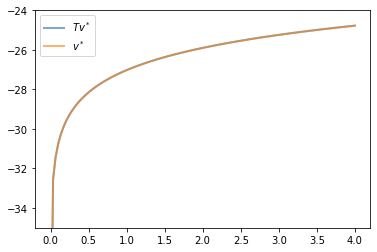

In [30]:
grid = og.grid

v_init = v_star(grid, α, og.β, og.μ)    # Start at the solution
c_opt, v = T(v_init, og)             # Apply T once

fig, ax = plt.subplots()
ax.set_ylim(-35, -24)
ax.plot(grid, v, lw=2, alpha=0.6, label='$Tv^*$')
ax.plot(grid, v_init, lw=2, alpha=0.6, label='$v^*$')
ax.legend()
plt.show()

The two functions are essentially indistinguishable, so we are off to a good start.

Now let’s have a look at iterating with the Bellman operator, starting
from an arbitrary initial condition.

The initial condition we’ll start with is, somewhat arbitrarily, $ V(y) = 5 \ln (y) $.

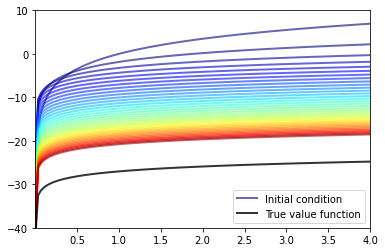

In [31]:
v = 5 * np.log(grid)  # An initial condition
n = 35

fig, ax = plt.subplots()

ax.plot(grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Initial condition')

for i in range(n):
    c_opt, v = T(v, og)  # Apply the Bellman operator
    ax.plot(grid, v, color=plt.cm.jet(i / n), lw=2, alpha=0.6)

ax.plot(grid, v_star(grid, α, og.β, og.μ), 'k-', lw=2,
        alpha=0.8, label='True value function')

ax.legend()
ax.set(ylim=(-40, 10), xlim=(np.min(grid), np.max(grid)))
plt.show()

The figure shows

1. the first 36 functions generated by the fitted value function iteration algorithm, with hotter colors given to higher iterates  
1. the true value function $ V^* $ drawn in black  

The sequence of iterates converges towards $ V^* $.

We are clearly getting closer.

#### Iterating to Convergence

We can write a function that iterates until the difference is below a particular
tolerance level.

In [51]:
def solve_model(og,
                tol=1e-4,
                max_iter=1000,
                verbose=True,
                print_skip=25):
    """
    Solve model by iterating with the Bellman operator.

    """

    # Set up loop
    v = og.u(og.grid)  # Initial condition
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:
        c_opt, v_new = T(v, og)
        error = np.max(np.abs(v - v_new))
        i += 1
        if verbose and i % print_skip == 0:
            print(f"Error at iteration {i} is {error}.")
        v = v_new

    if i == max_iter:
        print("Failed to converge!")

    if verbose and i < max_iter:
        print(f"\nConverged in {i} iterations.")

    return c_opt, v_new

Let’s use this function to compute an approximate solution at the defaults.

In [52]:
c_opt, v_solution = solve_model(og)

Error at iteration 25 is 0.40975776844490497.
Error at iteration 50 is 0.1476753540823772.
Error at iteration 75 is 0.05322171277213883.
Error at iteration 100 is 0.019180930548646558.
Error at iteration 125 is 0.006912744396029069.
Error at iteration 150 is 0.002491330384817303.
Error at iteration 175 is 0.000897867291303811.
Error at iteration 200 is 0.00032358842396718046.
Error at iteration 225 is 0.00011662020561331587.

Converged in 229 iterations.


Now we check our result by plotting it against the true value:

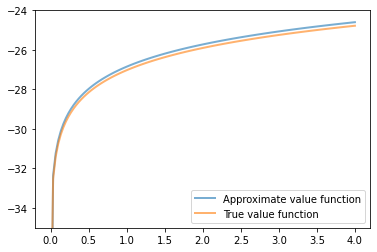

In [53]:
fig, ax = plt.subplots()

ax.plot(grid, v_solution, lw=2, alpha=0.6,
        label='Approximate value function')

ax.plot(grid, v_star(grid, α, og.β, og.μ), lw=2,
        alpha=0.6, label='True value function')

ax.legend()
ax.set_ylim(-35, -24)
plt.show()

The figure shows that we are pretty much on the money.

#### The optimal consumption

The policy `c_opt` computed above corresponds to an approximate optimal policy.

The next figure compares it to the exact solution, which, as mentioned
above, is $ \sigma(y) = (1 - \alpha \beta) y $

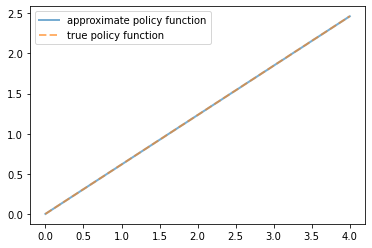

In [54]:
fig, ax = plt.subplots()

ax.plot(grid, c_opt, lw=2,
        alpha=0.6, label='approximate policy function')

ax.plot(grid, σ_star(grid, α, og.β), '--',
        lw=2, alpha=0.6, label='true policy function')

ax.legend()
plt.show()

The figure shows that we’ve done a good job in this instance of approximating
the true policy.

### Exercises

### Exercise 1

A common choice for utility function in this kind of work is the CRRA
specification

$$
u(c) = \frac{c^{1 - \gamma}} {1 - \gamma}
$$

Maintaining the other defaults, including the Cobb-Douglas production
function,  solve the optimal growth model with this
utility specification.

Setting $ \gamma = 1.5 $, compute and plot an estimate of the optimal policy.

Time how long this function takes to run, so you can compare it to faster code developed in the [next lecture](https://python-programming.quantecon.org/optgrowth_fast.html).


<a id='og-ex2'></a>

### Exercise 2

Time how long it takes to iterate with the Bellman operator
20 times, starting from initial condition $ v(y) = u(y) $.

Use the model specification in the previous exercise.

(As before, we will compare this number with that for the faster code developed in the [next lecture](https://python-programming.quantecon.org/optgrowth_fast.html).)

## Solutions

### Exercise 1

Here we set up the model.

In [55]:
γ = 1.5   # Preference parameter

def u_crra(c):
    return (c**(1 - γ) - 1) / (1 - γ)

og = OptimalGrowthModel(u=u_crra, f=fcd)

Now let’s run it, with a timer.

In [56]:
%%time
c_opt, v_solution = solve_model(og)

Error at iteration 25 is 0.5528151810417512.
Error at iteration 50 is 0.19923228425590978.
Error at iteration 75 is 0.07180266113800826.
Error at iteration 100 is 0.025877443335843964.
Error at iteration 125 is 0.009326145618970827.
Error at iteration 150 is 0.003361112262005861.
Error at iteration 175 is 0.0012113338243295857.
Error at iteration 200 is 0.0004365607333056687.
Error at iteration 225 is 0.00015733505506432266.

Converged in 237 iterations.
CPU times: user 28.5 s, sys: 3.8 ms, total: 28.5 s
Wall time: 28.6 s


Let’s plot the policy function just to see what it looks like:

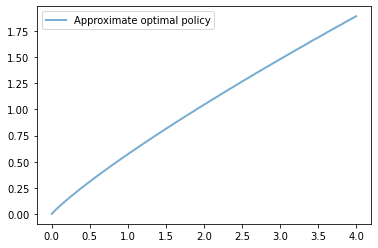

In [57]:
fig, ax = plt.subplots()

ax.plot(grid, c_opt, lw=2,
        alpha=0.6, label='Approximate optimal policy')

ax.legend()
plt.show()

### Exercise 2

Let’s set up:

In [58]:
og = OptimalGrowthModel(u=u_crra, f=fcd)
v = og.u(og.grid)

Here’s the timing:

In [59]:
%%time

for i in range(20):
    c_opt, v_new = T(v, og)
    v = v_new

CPU times: user 2.37 s, sys: 2.97 ms, total: 2.37 s
Wall time: 2.38 s
